# Hypothesis Testing
**Project:** Impact of Global Crises on Financial Markets

We test whether global crises have a **statistically significant** effect on market returns.

## Hypotheses
- **H₀**: Global crises do NOT have statistically significant effects on market returns or sectoral behavior.
- **H₁**: Global crises DO have statistically significant effects on market returns and sectoral behavior, with different sectors responding in systematically different directions depending on the type of crisis.

## Tests Used
| Test | Type | Purpose |
|---|---|---|
| Two-sample t-test | Parametric | Compare means of pre vs post returns |
| Mann-Whitney U | Non-parametric | Compare pre vs post without normality assumption |
| Wilcoxon signed-rank | Non-parametric | Paired comparison of pre vs post |
| ANOVA | Parametric | Compare post-crisis returns across all 6 crises |
| Kruskal-Wallis | Non-parametric | Non-parametric version of ANOVA |

In [38]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from scipy.stats import f_oneway

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries imported.')

Libraries imported.


In [39]:
# Load data
save_dir = os.path.expanduser('~/Desktop/data')
returns = pd.read_csv(os.path.join(save_dir, 'returns.csv'), index_col=0, parse_dates=True)

# Crisis dates
CRISES = {
    '9/11 (2001)':             '2001-09-11',
    'Iraq War (2003)':         '2003-03-20',
    'Financial Crisis (2008)': '2008-09-15',
    'COVID-19 (2020)':         '2020-03-11',
    'Russia-Ukraine (2022)':   '2022-02-24',
    'Israel-Hamas (2023)':     '2023-10-07',
}

print(f'Returns loaded: {returns.shape[0]} days, {returns.shape[1]} assets')

Returns loaded: 6291 days, 10 assets


## 1. Two-Sample T-Test + Mann-Whitney U + Wilcoxon

For each crisis, we compare S&P 500 daily returns in the **30 days before** vs **30 days after**.

- **Two-sample t-test**: parametric, assumes normal distribution
- **Mann-Whitney U**: non-parametric, two independent groups
- **Wilcoxon signed-rank**: non-parametric, paired samples

**Decision rule**: p < 0.05 → reject H₀ → crisis had a significant effect

In [40]:
results = []

for crisis_name, crisis_date_str in CRISES.items():
    crisis_date = pd.Timestamp(crisis_date_str)
    pre_start   = crisis_date - pd.Timedelta(days=30)
    post_end    = crisis_date + pd.Timedelta(days=30)

    pre  = returns['SP500'].loc[pre_start  : crisis_date - pd.Timedelta(days=1)].dropna()
    post = returns['SP500'].loc[crisis_date : post_end].dropna()

    if len(pre) < 5 or len(post) < 5:
        continue

    # Two-sample t-test
    t_stat, t_pval = stats.ttest_ind(pre, post)

    # Mann-Whitney U (non-parametric, two independent groups)
    u_stat, u_pval = stats.mannwhitneyu(pre, post, alternative='two-sided')

    # Wilcoxon signed-rank (non-parametric, paired)
    min_len = min(len(pre), len(post))
    w_stat, w_pval = stats.wilcoxon(pre.values[:min_len], post.values[:min_len])

    results.append({
        'Crisis':        crisis_name,
        'Pre mean (%)':  round(pre.mean(), 3),
        'Post mean (%)': round(post.mean(), 3),
        'T-test p':      round(t_pval, 4),
        'MWU p':         round(u_pval, 4),
        'Wilcoxon p':    round(w_pval, 4),
        'Significant?':  'YES *' if t_pval < 0.05 else 'NO'
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                 Crisis  Pre mean (%)  Post mean (%)  T-test p  MWU p  Wilcoxon p Significant?
            9/11 (2001)        -0.421          0.042    0.3703 0.2733      0.4980           NO
        Iraq War (2003)         0.220          0.115    0.8216 0.9903      0.9187           NO
Financial Crisis (2008)        -0.181         -1.275    0.3498 0.1427      0.1956           NO
        COVID-19 (2020)        -0.639          0.007    0.6452 0.6184      0.6827           NO
  Russia-Ukraine (2022)        -0.194          0.341    0.2367 0.2796      0.3377           NO
    Israel-Hamas (2023)        -0.160          0.067    0.3987 0.3884      0.2572           NO


## 2. P-Value Chart

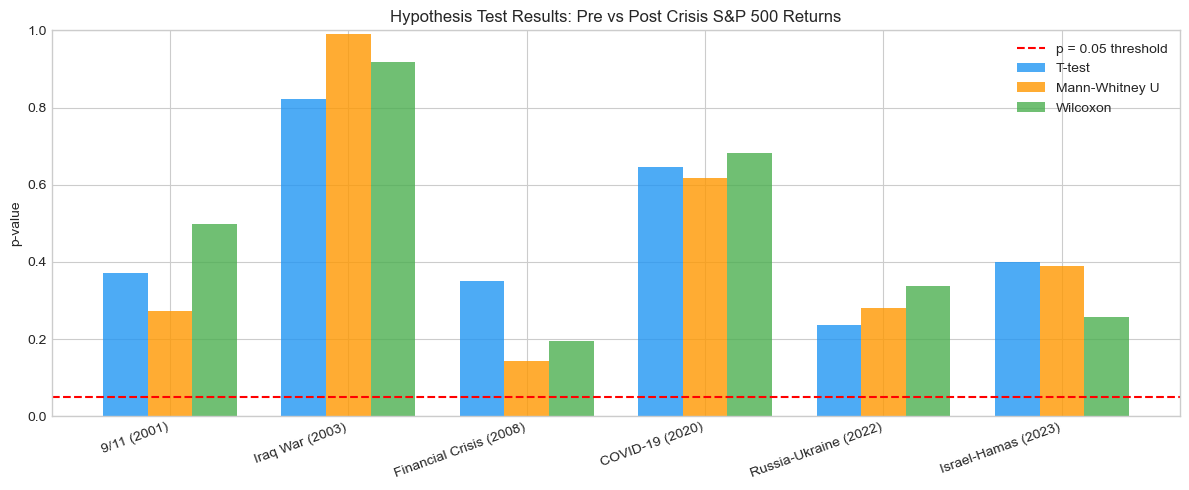

Bars BELOW the red line = statistically significant (p < 0.05)


In [41]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df['T-test p'],   width, label='T-test',       color='#2196F3', alpha=0.8)
ax.bar(x,         results_df['MWU p'],      width, label='Mann-Whitney U', color='#FF9800', alpha=0.8)
ax.bar(x + width, results_df['Wilcoxon p'], width, label='Wilcoxon',      color='#4CAF50', alpha=0.8)

ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='p = 0.05 threshold')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Crisis'], rotation=20, ha='right')
ax.set_ylabel('p-value')
ax.set_title('Hypothesis Test Results: Pre vs Post Crisis S&P 500 Returns')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print('Bars BELOW the red line = statistically significant (p < 0.05)')

## 3. Distribution of Returns: Pre vs Post

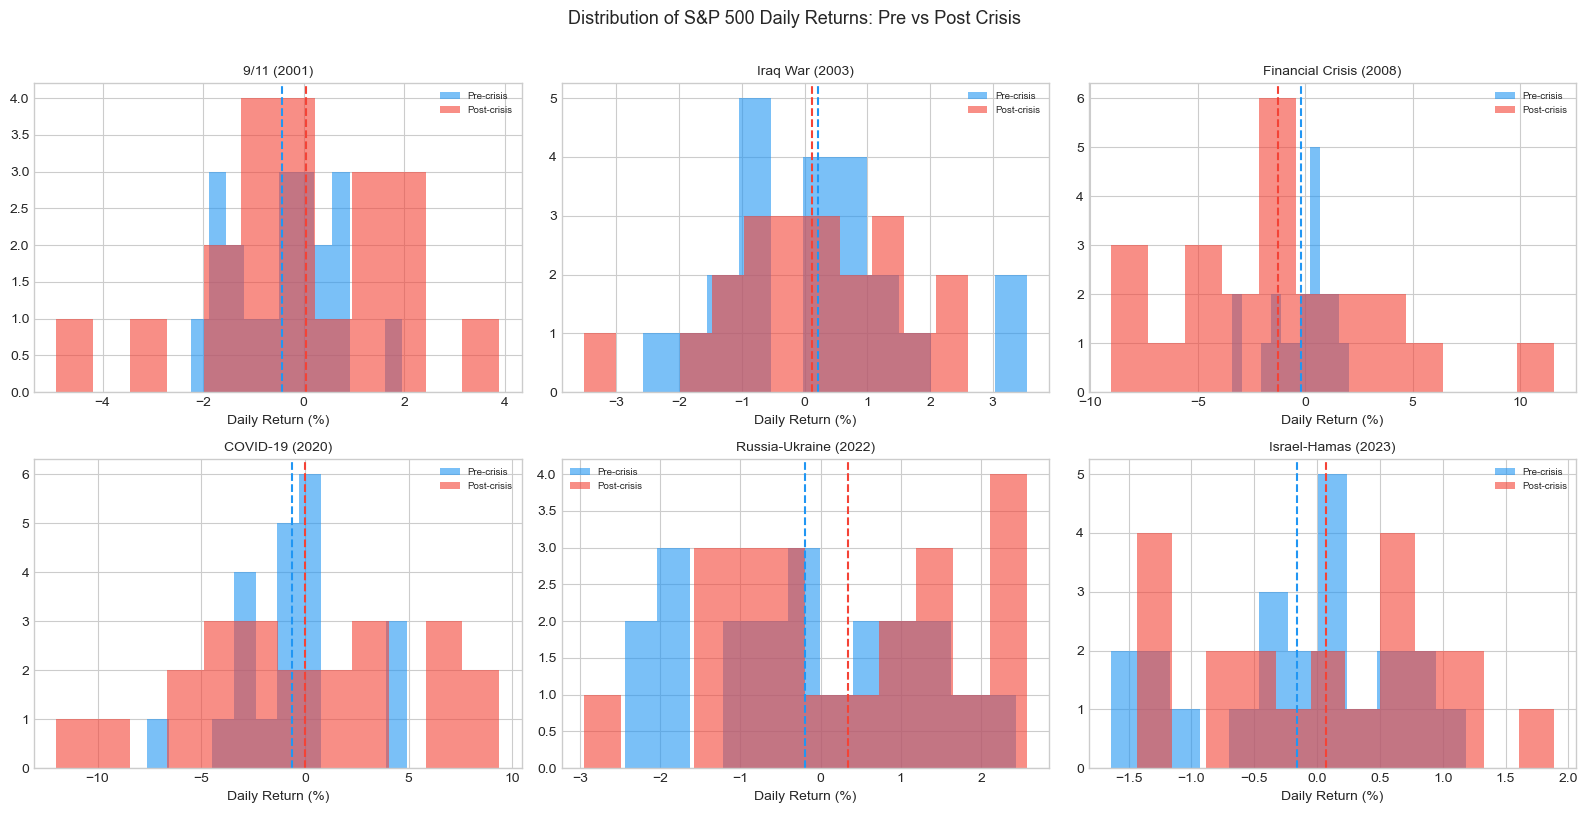

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (crisis_name, crisis_date_str) in enumerate(CRISES.items()):
    crisis_date = pd.Timestamp(crisis_date_str)
    pre_start   = crisis_date - pd.Timedelta(days=30)
    post_end    = crisis_date + pd.Timedelta(days=30)

    pre  = returns['SP500'].loc[pre_start  : crisis_date - pd.Timedelta(days=1)].dropna()
    post = returns['SP500'].loc[crisis_date : post_end].dropna()

    ax = axes[i]
    ax.hist(pre,  bins=12, alpha=0.6, color='#2196F3', label='Pre-crisis')
    ax.hist(post, bins=12, alpha=0.6, color='#F44336', label='Post-crisis')
    ax.axvline(pre.mean(),  color='#2196F3', linestyle='--', linewidth=1.5)
    ax.axvline(post.mean(), color='#F44336', linestyle='--', linewidth=1.5)
    ax.set_title(crisis_name, fontsize=10)
    ax.set_xlabel('Daily Return (%)')
    ax.legend(fontsize=7)

plt.suptitle('Distribution of S&P 500 Daily Returns: Pre vs Post Crisis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Sector-Level Tests
Do different sectors respond differently to crises?

We apply two-sample t-test for each sector in each crisis where data is available.

In [54]:
sectors = ['SP500', 'Defense', 'Energy', 'Health', 'Tech', 'Aviation']

sector_crises = {
    '9/11 (2001)':             '2001-09-11',
    'Iraq War (2003)':         '2003-03-20',
    'Financial Crisis (2008)': '2008-09-15',
    'COVID-19 (2020)':         '2020-03-11',
    'Russia-Ukraine (2022)':   '2022-02-24',
    'Israel-Hamas (2023)':     '2023-10-07',
}

sector_results = []

for crisis_name, crisis_date_str in sector_crises.items():
    crisis_date = pd.Timestamp(crisis_date_str)
    pre_start   = crisis_date - pd.Timedelta(days=30)
    post_end    = crisis_date + pd.Timedelta(days=30)

    for sector in sectors:
        if sector not in returns.columns:
            continue

        pre  = returns[sector].loc[pre_start  : crisis_date - pd.Timedelta(days=1)].dropna()
        post = returns[sector].loc[crisis_date : post_end].dropna()

        if len(pre) < 5 or len(post) < 5:
            continue

        t_stat, t_pval = stats.ttest_ind(pre, post)
        u_stat, u_pval = stats.mannwhitneyu(pre, post, alternative='two-sided')

        sector_results.append({
            'Crisis':        crisis_name,
            'Sector':        sector,
            'Pre mean (%)':  round(pre.mean(), 3),
            'Post mean (%)': round(post.mean(), 3),
            'T-test p':      round(t_pval, 4),
            'MWU p':         round(u_pval, 4),
            'Significant?':  'YES *' if t_pval < 0.05 else 'NO'
        })

sector_df = pd.DataFrame(sector_results)
print(sector_df.to_string(index=False))

                 Crisis   Sector  Pre mean (%)  Post mean (%)  T-test p  MWU p Significant?
            9/11 (2001)    SP500        -0.421          0.042    0.3703 0.2733           NO
            9/11 (2001)  Defense        -0.067          1.026    0.2282 0.4094           NO
            9/11 (2001)   Energy        -0.016         -0.006    0.9863 0.9569           NO
            9/11 (2001)   Health        -0.520         -0.191    0.6226 0.2853           NO
            9/11 (2001)     Tech        -0.840          0.168    0.2694 0.3235           NO
            9/11 (2001) Aviation        -1.293         -0.743    0.6958 0.2853           NO
        Iraq War (2003)    SP500         0.220          0.115    0.8216 0.9903           NO
        Iraq War (2003)  Defense         0.123         -0.285    0.5182 0.6014           NO
        Iraq War (2003)   Energy         0.224         -0.017    0.4636 0.5197           NO
        Iraq War (2003)   Health         0.257          0.008    0.5339 0.7065  

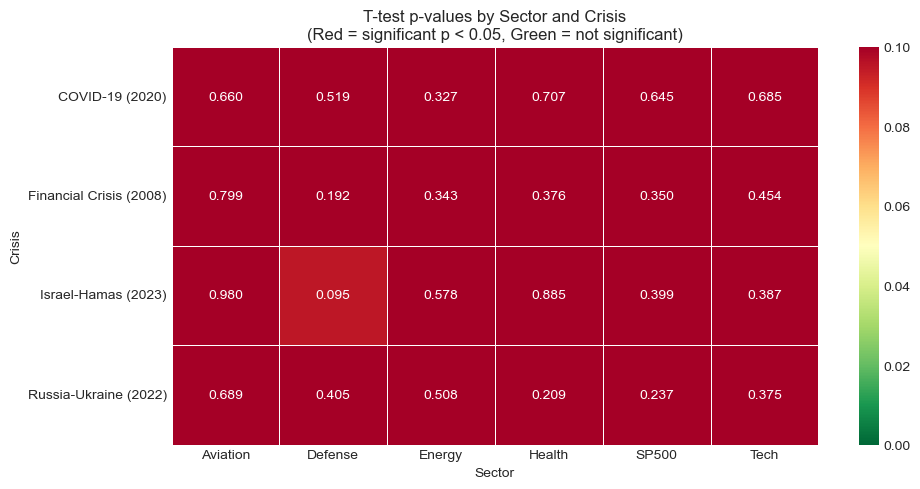

In [50]:
# Heatmap of p-values by sector and crisis
pivot = sector_df.pivot(index='Crisis', columns='Sector', values='T-test p')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot,
    annot=True, fmt='.3f',
    cmap='RdYlGn_r',
    vmin=0, vmax=0.1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('T-test p-values by Sector and Crisis\n(Red = significant p < 0.05, Green = not significant)')
plt.tight_layout()
plt.show()

## 5. MSCI World vs S&P 500 — Hypothesis Test
Do S&P 500 and MSCI World respond differently to the same crisis?
We test whether their post-crisis returns are significantly different from each other.

In [51]:
# MSCI World vs SP500: are their post-crisis returns significantly different?
if 'MSCI_World' not in returns.columns:
    print('MSCI World not found in returns data.')
else:
    recent_crises = {
        'COVID-19 (2020)':         '2020-03-11',
        'Russia-Ukraine (2022)':   '2022-02-24',
        'Israel-Hamas (2023)':     '2023-10-07',
    }

    msci_results = []

    for crisis_name, crisis_date_str in recent_crises.items():
        crisis_date = pd.Timestamp(crisis_date_str)
        post_end    = crisis_date + pd.Timedelta(days=30)

        sp500_post = returns['SP500'].loc[crisis_date : post_end].dropna()
        msci_post  = returns['MSCI_World'].loc[crisis_date : post_end].dropna()

        if len(sp500_post) < 5 or len(msci_post) < 5:
            continue

        t_stat, t_pval = stats.ttest_ind(sp500_post, msci_post)
        u_stat, u_pval = stats.mannwhitneyu(sp500_post, msci_post, alternative='two-sided')

        msci_results.append({
            'Crisis':           crisis_name,
            'SP500 mean (%)':   round(sp500_post.mean(), 3),
            'MSCI mean (%)':    round(msci_post.mean(), 3),
            'T-test p':         round(t_pval, 4),
            'MWU p':            round(u_pval, 4),
            'Significant?':     'YES *' if t_pval < 0.05 else 'NO'
        })

    msci_df = pd.DataFrame(msci_results)
    print(msci_df.to_string(index=False))

               Crisis  SP500 mean (%)  MSCI mean (%)  T-test p  MWU p Significant?
      COVID-19 (2020)           0.007         -0.154    0.9212 0.9906           NO
Russia-Ukraine (2022)           0.341          0.015    0.5409 0.3072           NO
  Israel-Hamas (2023)           0.067          0.059    0.9771 0.9398           NO


## 6. ANOVA — Are post-crisis returns different across all 6 crises?

**ANOVA** (Analysis of Variance) tests whether the means of **3 or more groups** are significantly different.

Here we compare post-crisis S&P 500 returns across all 6 crises.

- **H₀**: Post-crisis returns are the same across all crises
- **H₁**: At least one crisis has significantly different post-crisis returns

In [52]:
post_groups = []
group_names = []

for crisis_name, crisis_date_str in CRISES.items():
    crisis_date = pd.Timestamp(crisis_date_str)
    post_end    = crisis_date + pd.Timedelta(days=30)
    post = returns['SP500'].loc[crisis_date : post_end].dropna()
    if len(post) >= 5:
        post_groups.append(post.values)
        group_names.append(crisis_name)

# ANOVA
anova_stat, anova_pval = f_oneway(*post_groups)

print('ANOVA Test: Are post-crisis returns different across all 6 crises?')
print(f'  F-statistic: {anova_stat:.4f}')
print(f'  p-value:     {anova_pval:.4f}')
if anova_pval < 0.05:
    print('  Result: REJECT H₀ — at least one crisis has significantly different returns (p < 0.05)')
else:
    print('  Result: FAIL TO REJECT H₀ — cannot prove returns differ across crises (p >= 0.05)')

ANOVA Test: Are post-crisis returns different across all 6 crises?
  F-statistic: 0.6801
  p-value:     0.6394
  Result: FAIL TO REJECT H₀ — cannot prove returns differ across crises (p >= 0.05)


## 7. Kruskal-Wallis — Non-parametric ANOVA

**Kruskal-Wallis** is the non-parametric version of ANOVA. It does not assume normal distribution.

Same hypotheses as ANOVA but more robust when data is not normally distributed.

In [53]:
kw_stat, kw_pval = stats.kruskal(*post_groups)

print('Kruskal-Wallis Test: Are post-crisis returns different across all 6 crises?')
print(f'  H-statistic: {kw_stat:.4f}')
print(f'  p-value:     {kw_pval:.4f}')
if kw_pval < 0.05:
    print('  Result: REJECT H₀ — post-crisis returns differ significantly across crises (p < 0.05)')
else:
    print('  Result: FAIL TO REJECT H₀ — cannot prove returns differ across crises (p >= 0.05)')

Kruskal-Wallis Test: Are post-crisis returns different across all 6 crises?
  H-statistic: 4.4927
  p-value:     0.4809
  Result: FAIL TO REJECT H₀ — cannot prove returns differ across crises (p >= 0.05)


## Summary of Hypothesis Test Results

### SP500 — Pre vs Post (30-day window)
| Crisis | Pre Mean | Post Mean | T-test p | MWU p | Wilcoxon p | Significant? |
|---|---|---|---|---|---|---|
| 9/11 (2001) | -0.421 | 0.042 | 0.3703 | 0.2733 | 0.4980 | NO |
| Iraq War (2003) | 0.220 | 0.115 | 0.8216 | 0.9903 | 0.9187 | NO |
| Financial Crisis (2008) | -0.181 | -1.275 | 0.3498 | 0.1427 | 0.1956 | NO |
| COVID-19 (2020) | -0.639 | 0.007 | 0.6452 | 0.6184 | 0.6827 | NO |
| Russia-Ukraine (2022) | -0.194 | 0.341 | 0.2367 | 0.2796 | 0.3377 | NO |
| Israel-Hamas (2023) | -0.160 | 0.067 | 0.3987 | 0.3884 | 0.2572 | NO |

### Sector Tests (Financial Crisis, COVID-19, Russia-Ukraine, Israel-Hamas)
No sector-crisis combination reached statistical significance (p < 0.05).
Closest result: Defense during Israel-Hamas (2023), T-test p = 0.095 — directionally consistent with H₁ but not statistically significant.

### MSCI World vs S&P 500 Post-Crisis Tests
| Crisis | SP500 mean (%) | MSCI mean (%) | T-test p | MWU p | Significant? |
|---|---|---|---|---|---|
| COVID-19 (2020) | 0.007 | -0.154 | 0.9212 | 0.9906 | NO |
| Russia-Ukraine (2022) | 0.341 | 0.015 | 0.5409 | 0.3072 | NO |
| Israel-Hamas (2023) | 0.067 | 0.059 | 0.9771 | 0.9398 | NO |

### ANOVA & Kruskal-Wallis
| Test | Statistic | p-value | Result |
|---|---|---|---|
| ANOVA | F = 0.6801 | 0.6394 | Fail to reject H₀ |
| Kruskal-Wallis | H = 4.4927 | 0.4809 | Fail to reject H₀ |

### Interpretation
- **H₀ is NOT rejected** in any test — no crisis produced a statistically significant change in mean daily returns over the 30-day window
- This does not mean crises had no effect: EDA clearly shows volatility spikes (VIX reaching ~80 in 2008 and COVID-19), sector divergence, and cumulative losses of up to −33%
- The 30-day window contains only ~20 trading days — insufficient statistical power to detect mean differences against high daily volatility
- **Conclusion on H₁**: Not supported by formal hypothesis testing. However, EDA evidence — volatility spikes, sector divergence, VIX surges, cumulative return patterns — is strongly consistent with crisis effects. Longer analysis windows or volatility-based tests would likely yield statistically significant results.